In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_s = pd.read_csv(r"C:\Users\Vivek\Downloads\S_seaice_extent_daily_v4.0.csv")
df_n = pd.read_csv(r"C:\Users\Vivek\Downloads\N_seaice_extent_daily_v4.0.csv")

# Overview

In [4]:
df_s.head()

,year,month,day,extent,hemisphere
0,1978,10,26,17.624,South
1,1978,10,28,17.803,South
2,1978,10,30,17.670,South
3,1978,11,1,17.527,South
4,1978,11,3,17.486,South


In [5]:
df_n.head()

,year,month,day,extent,hemisphere
0,1978,10,26,10.231,North
1,1978,10,28,10.420,North
2,1978,10,30,10.557,North
3,1978,11,1,10.670,North
4,1978,11,3,10.777,North


In [6]:
df_s.describe()

,year,month,day,extent
count,15780.000000,15780.000000,15780.000000,15780.000000
mean,2004.201965,6.509379,15.731305,11.508098
std,12.878557,3.446564,8.801098,5.633833
min,1978.000000,1.000000,1.000000,1.848000
25%,1994.000000,4.000000,8.000000,5.921000
50%,2004.000000,7.000000,16.000000,12.358000
75%,2015.000000,10.000000,23.000000,17.022000
max,2026.000000,12.000000,31.000000,20.201000


In [7]:
df_n.describe()

,year,month,day,extent
count,15780.000000,15780.000000,15780.000000,15780.000000
mean,2004.201965,6.509379,15.731305,11.194876
std,12.878557,3.446564,8.801098,3.323855
min,1978.000000,1.000000,1.000000,3.340000
25%,1994.000000,4.000000,8.000000,8.436500
50%,2004.000000,7.000000,16.000000,11.937000
75%,2015.000000,10.000000,23.000000,14.107250
max,2026.000000,12.000000,31.000000,16.635000


# Distribution of Extent

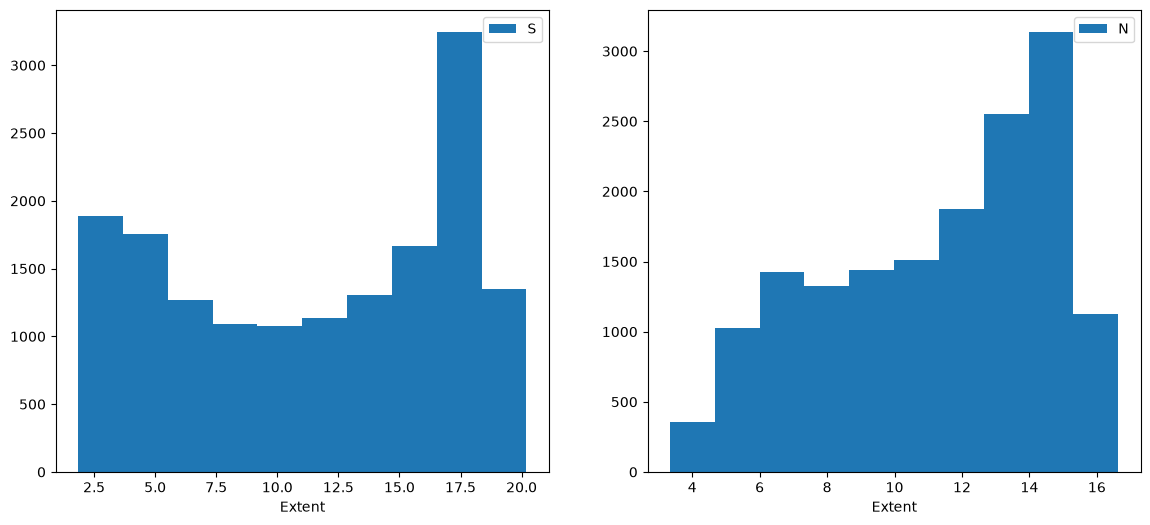

In [14]:
fig, ax = plt.subplots(1,2,figsize = (14,6))
ax[0].hist(df_s['extent'],bins =10)
ax[0].set_xlabel("Extent")
ax[0].legend("South")

ax[1].hist(df_n['extent'],bins=10)
ax[1].set_xlabel("Extent")
ax[1].legend("North")
#plt.tight_layout()


## Insights
##### south - extent is increasing and decreasing
##### north - extent is reducing

# Year wise average extent of ice

In [16]:
df_s_yearwise_extent = df_s.groupby('year')['extent'].mean()
df_n_yearwise_extent = df_n.groupby('year')['extent'].mean()

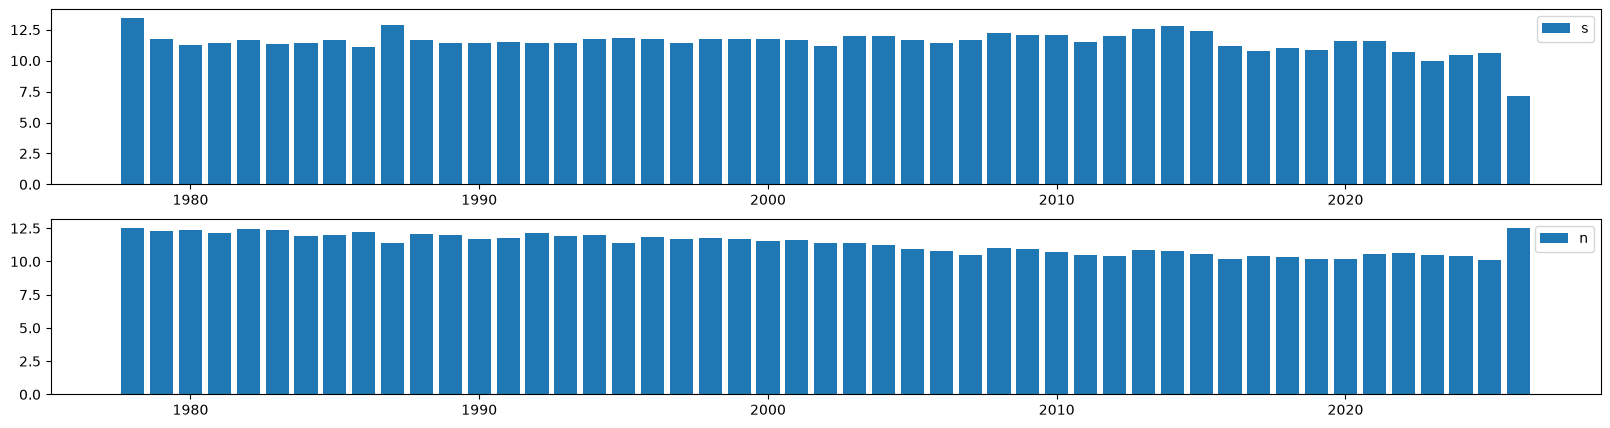

In [17]:
fig, ax = plt.subplots(2,1,figsize = (20,5))
ax[0].bar(df_s_yearwise_extent.index, height = df_s_yearwise_extent)
ax[0].legend("south")

ax[1].bar(df_n_yearwise_extent.index, height = df_n_yearwise_extent)
ax[1].legend("north")

#plt.tight_layout()

## Insights
##### North region ice is decreasing
##### South region ice is volatile

# Year and month wise average

In [ ]:
df_s.shape[0]

26354

In [ ]:
df_s.iloc[0,:]

year            1978
month             10
day               26
Extent        10.231
hemisphere     north
Name: 0, dtype: object

In [ ]:
df_s.iloc[(df_s.shape[0]) -1,:]

year            2019
month              5
day               31
Extent        10.436
hemisphere     south
Name: 26353, dtype: object

In [18]:
df_s_yearmonthwise_extent = df_s.groupby(['year','month'])['extent'].mean()
df_n_yearmonthwise_extent = df_n.groupby(['year','month'])['extent'].mean()

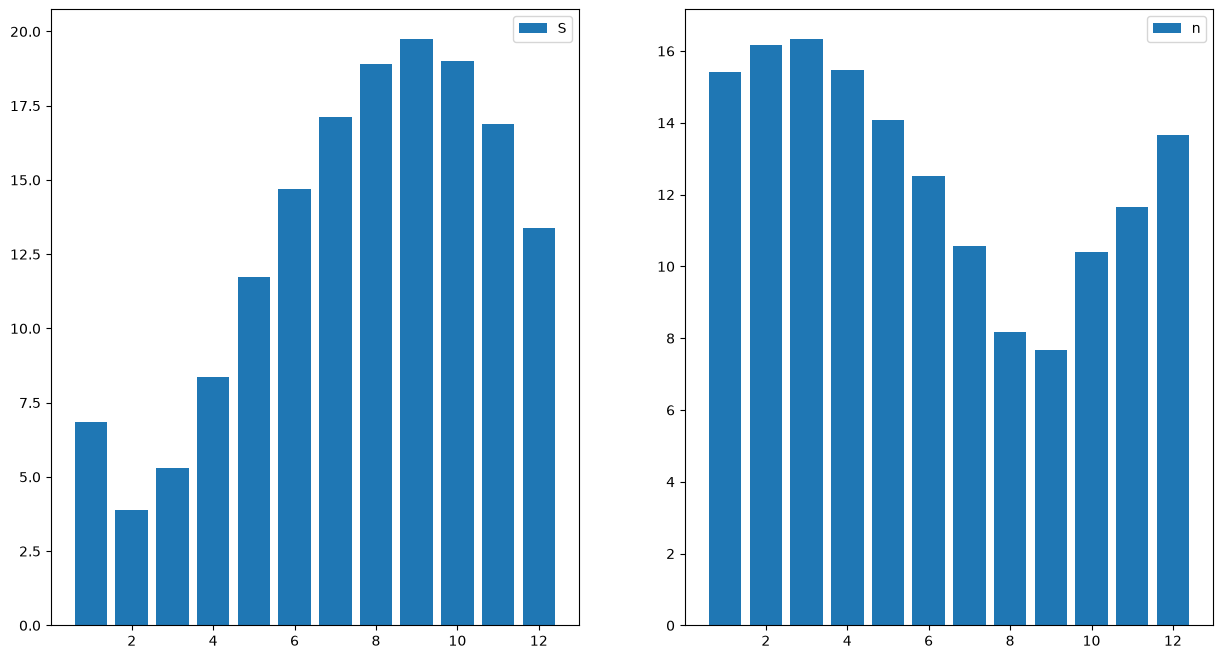

In [21]:
fig, ax = plt.subplots(1,2,figsize = (15,8))
ax[0].bar(df_s_yearmonthwise_extent.index.get_level_values(1),df_s_yearmonthwise_extent)
ax[0].legend("South")
ax[1].bar(df_n_yearmonthwise_extent.index.get_level_values(1),df_n_yearmonthwise_extent)
ax[1].legend("north")

## Insgiths
##### south - more ice at the ending months of the year
##### north - more ice at the staring months of the year

# Year to Year increase or decrease

In [24]:
df_s_yearwise_extent.iloc[0]

np.float64(13.466676470588236)

In [33]:
array1 = []
array2 = []
#columns = ['north', 'south']

for j in range(1,df_s_yearwise_extent.shape[0]):
    diff = (df_s_yearwise_extent.iloc[j]) - (df_s_yearwise_extent.iloc[j - 1])
    # print(f"{yearwise_extent_unstack.iloc[j,i]}:{diff}" )
    array1.append(diff)

for j in range(1,df_n_yearwise_extent.shape[0]):
    diff = (df_n_yearwise_extent.iloc[j]) - (df_n_yearwise_extent.iloc[j - 1])
    # print(f"{yearwise_extent_unstack.iloc[j,i]}:{diff}" )
    array2.append(diff)


In [34]:
dict_diff = {
    "south" : pd.Series(array1),
    "north" : pd.Series(array2)
} 
df_diff = pd.DataFrame(dict_diff)
df_diff.head()

,south,north
0,-1.747539,-0.167440
1,-0.482848,0.014587
2,0.180519,-0.198661
3,0.241257,0.303959
4,-0.288153,-0.103549


In [35]:
df_diff.shape

(48, 2)

In [28]:
df_s_yearwise_extent.index[1:]

Index([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
      dtype='int64', name='year')

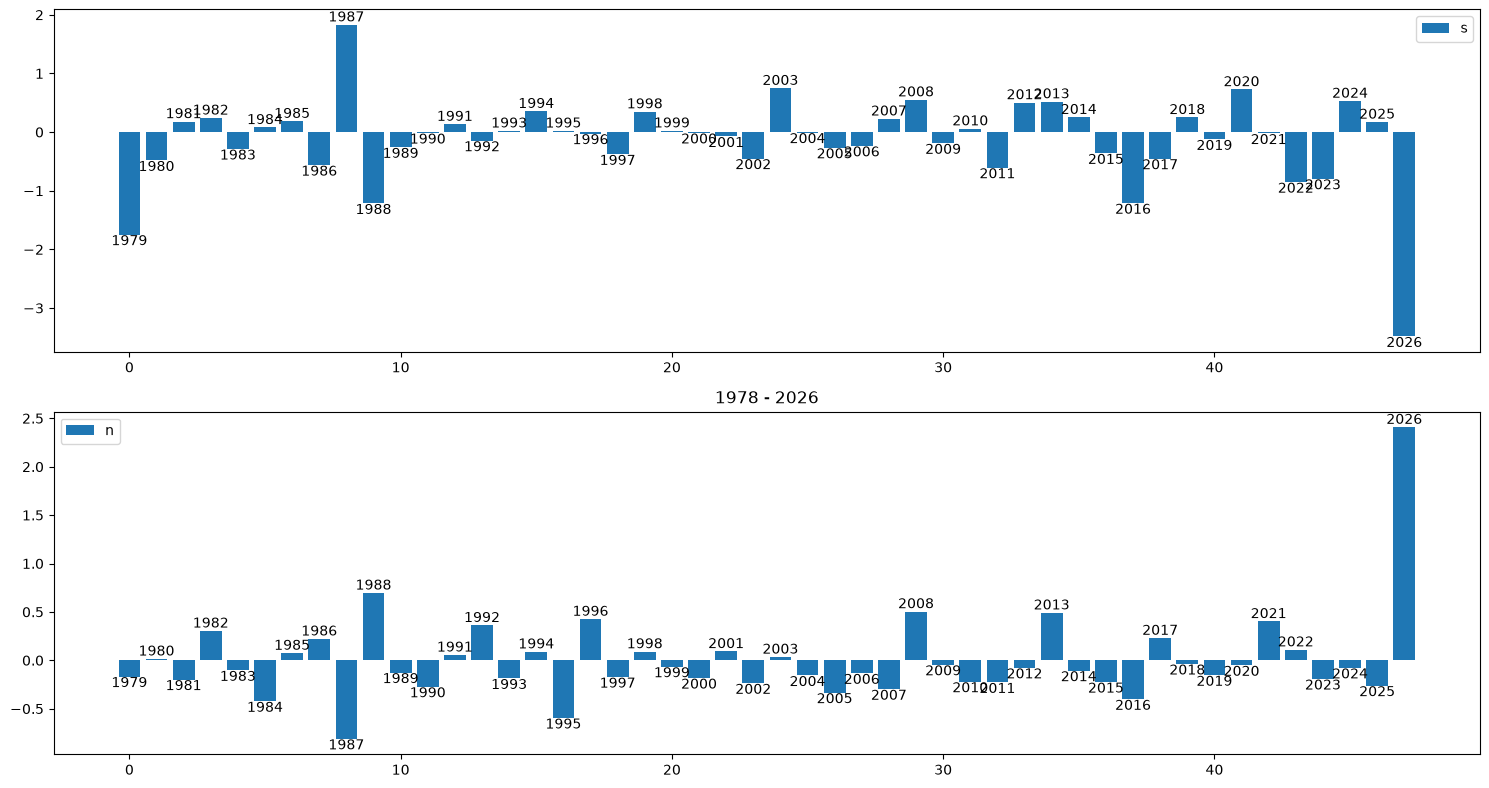

In [36]:
fig, ax = plt.subplots(2,1,figsize = (15,8))
bars = ax[0].bar(df_diff.index, height = df_diff['south'])
ax[0].legend("south")
ax[0].bar_label(bars,df_s_yearwise_extent.index[1:])

barn = ax[1].bar(df_diff.index, height = df_diff['north'])
ax[1].legend("north")
ax[1].bar_label(barn,df_n_yearwise_extent.index[1:])

plt.title(label="1978 - 2026")
plt.tight_layout()


## Insights
##### In this also we can see, northen hemisphere ice extent is reducing as year
##### south - 2026 low because, in starting months extent is low
##### north - 2026 high becasue, in starting months extent is high